# Preparación de datos

**Conjunto de datos:** Dataset 8 - Matriz Estación - Empresa

**Nombre de archivo:** stations_permits_matrix.csv

## 0. Inicialización

Instalar ydata-profiling

In [67]:
!pip install ydata-profiling

Instalar haversine

In [68]:
!pip install haversine

Importaciones

In [69]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
import seaborn as sns

from haversine import haversine, Unit
from tabulate import tabulate

Visualización de tablas y gráficas

In [70]:
sns.set_style("darkgrid")

def print_table(df):
    print(tabulate(df, headers='keys', tablefmt='simple_outline'))

Lectura y muestra del archivo

In [71]:
stations = pd.read_csv('../data/original/air_quality_stations.csv')
permits = pd.read_csv('../data/preparada/emission_permits.csv')
measurements = pd.read_csv('../data/preparada/measurements.csv')
probabilities = pd.read_csv('../data/preparada/variable_permits_matrix.csv')
variables = pd.read_csv('../data/enriquecida/variables.csv')

**1.** Eliminar columnas

In [72]:
stations = stations[['id', 'latitude', 'longitude']]
stations

,id,latitude,longitude
0,8,4.530214,-74.142217
1,18,4.940316,-73.970698
2,20,5.200000,-73.883000
3,4,4.596229,-74.194715
4,6,4.695702,-74.215583
5,17,4.862871,-74.056341
6,16,4.298055,-74.819167
7,23,4.594991,-74.204826
8,14,4.716525,-74.211712
9,22,4.809444,-74.102500


In [73]:
permits = permits[['ID', 'Latitud', 'Longitud']]
permits

,ID,Latitud,Longitud
0,1,4.703418,-74.226561
1,2,5.318407,-73.704281
2,3,4.800462,-74.210355
3,4,4.678797,-74.284112
4,5,4.699590,-74.193752
...,...,...,...
531,540,5.496933,-73.625257
532,541,4.274013,-74.446186
533,542,5.228254,-73.817856
534,543,4.303990,-74.803157


In [74]:
measurements = measurements[['station', 'variable']]
measurements

,station,variable
0,3,WDS
1,2,NO
2,18,RAIN
3,18,WDS
4,3,Temp
...,...,...
380091,14,WDS
380092,14,PM10
380093,9,PM10
380094,4,SO2


In [75]:
variables = variables[['Variable', 'Rango promedio Km']]
variables

,Variable,Rango promedio Km
0,PM10,17.0
1,PM2.5,30.0
2,SO2,15.0
3,NO2,8.0
4,NO,6.0
5,NOX,12.0
6,CO,5.0
7,Temp,NaN
8,RAIN,NaN
9,WDS,NaN


**2.** Eliminar duplicados

In [76]:
measurements = measurements.drop_duplicates()
measurements

,station,variable
0,3,WDS
1,2,NO
2,18,RAIN
3,18,WDS
4,3,Temp
...,...,...
188612,8,SO2
192862,10,NO
192880,10,PM10
192884,10,NOX


**3.** Renombrar columnas

In [77]:
stations = stations.rename(columns={
    'id': 'IDEstación',
    'latitude': 'LatitudEstación',
    'longitude': 'LongitudEstación'
})

permits = permits.rename(columns={
    'ID': 'IDEmpresa',
    'Latitud': 'LatitudEmpresa',
    'Longitud': 'LongitudEmpresa'
})

measurements = measurements.rename(columns={
    'station': 'IDEstación',
    'variable': 'Variable'
})

**4.** Guardar distancias de estaciones a empresas cuando tiene una distancia menor o igual a 100 kms a la redonda

In [78]:
# Crear el producto cartesiano de todas las estaciones con todos los permisos
arcos = stations[['IDEstación', 'LatitudEstación', 'LongitudEstación']].merge(
    permits[['IDEmpresa', 'LatitudEmpresa', 'LongitudEmpresa']], 
    how='cross'
)

# Calcular la distancia haversine para cada par
arcos['DistanciaKm'] = arcos.apply(
    lambda row: haversine(
        (row['LatitudEstación'], row['LongitudEstación']),
        (row['LatitudEmpresa'], row['LongitudEmpresa']),
        unit=Unit.KILOMETERS
    ),
    axis=1
)

# Filtrar solo los arcos con distancia
df = arcos[arcos['DistanciaKm'] <= 100].copy()

# Mantener solo las columnas de IDs y distancia
df = df[['IDEstación', 'IDEmpresa', 'DistanciaKm']]

# Resetear el índice
df = df.reset_index(drop=True)
df

,IDEstación,IDEmpresa,DistanciaKm
0,8,1,21.408229
1,8,3,30.984546
2,8,4,22.810256
3,8,5,19.680815
4,8,6,78.465404
...,...,...,...
10799,5,539,83.609656
10800,5,541,35.842815
10801,5,542,91.303494
10802,5,543,66.739336


**5.** Obtener variables medidas por la estación, creando un arco por cada variable

In [79]:
df = df.merge(
    measurements, 
    how='inner',
    on='IDEstación'
)
df

,IDEstación,IDEmpresa,DistanciaKm,Variable
0,8,1,21.408229,NO2
1,8,1,21.408229,NO
2,8,1,21.408229,PM2.5
3,8,1,21.408229,SO2
4,8,3,30.984546,NO2
...,...,...,...,...
60272,5,544,10.770024,SO2
60273,5,544,10.770024,CO
60274,5,544,10.770024,WDD
60275,5,544,10.770024,RAIN


**6.** Obtener los rangos promedios de dispersión de las variables

In [80]:
df = df.merge(
    variables, 
    how='inner',
    on='Variable'
)
df

,IDEstación,IDEmpresa,DistanciaKm,Variable,Rango promedio Km
0,8,1,21.408229,NO2,8.0
1,8,1,21.408229,NO,6.0
2,8,1,21.408229,PM2.5,30.0
3,8,1,21.408229,SO2,15.0
4,8,3,30.984546,NO2,8.0
...,...,...,...,...,...
60272,5,544,10.770024,SO2,15.0
60273,5,544,10.770024,CO,5.0
60274,5,544,10.770024,WDD,NaN
60275,5,544,10.770024,RAIN,NaN


**7.** Obtener las probabilidades de emisión de las empresas

In [81]:
df = df.merge(
    probabilities, 
    how='inner',
    on=['IDEmpresa', 'Variable']
)
df

,IDEstación,IDEmpresa,DistanciaKm,Variable,Rango promedio Km,ProbabilidadEmision
0,8,1,21.408229,NO2,8.0,0.711111
1,8,1,21.408229,NO,6.0,0.711111
2,8,1,21.408229,PM2.5,30.0,0.800000
3,8,1,21.408229,SO2,15.0,0.511111
4,8,3,30.984546,NO2,8.0,0.888889
...,...,...,...,...,...,...
37650,5,543,66.739336,SO2,15.0,0.311111
37651,5,543,66.739336,CO,5.0,0.266667
37652,5,544,10.770024,PM10,17.0,0.422222
37653,5,544,10.770024,SO2,15.0,0.311111


**8.** Obtener las incidencias, a partir de las distancias, rangos de dispersión y probabilidades de emisión

In [82]:
df['Incidencia'] = round(df['ProbabilidadEmision'] * np.exp(-1/2 * (df['DistanciaKm'] / df['Rango promedio Km']) ** 2), 6)
df['Incidencia'].describe()

count    37655.000000
mean         0.106854
std          0.183461
min          0.000000
25%          0.000000
50%          0.005092
75%          0.142437
max          0.954320
Name: Incidencia, dtype: float64

In [83]:
df[df['DistanciaKm'] <= 20]['Incidencia'].describe()

count    8132.000000
mean        0.346026
std         0.228216
min         0.000024
25%         0.174029
50%         0.310433
75%         0.530931
max         0.954320
Name: Incidencia, dtype: float64

<Axes: title={'center': 'Distribución de Incidencias'}>

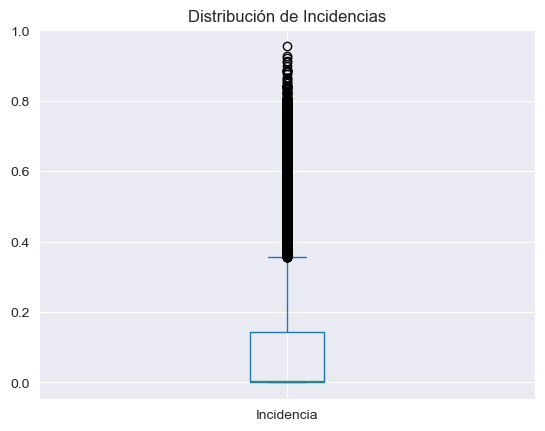

In [84]:
df['Incidencia'].plot(kind='box', title='Distribución de Incidencias')

**9.** Eliminar las columnas extra

In [85]:
df.drop(columns=['Rango promedio Km', 'ProbabilidadEmision'], inplace=True)

**13.** Ordenar por IDs

In [86]:
df.sort_values(by=['IDEstación', 'IDEmpresa', 'Variable'], inplace=True)

Resultado final

In [87]:
df

,IDEstación,IDEmpresa,DistanciaKm,Variable,Incidencia
29548,2,1,5.502287,NO,0.467005
29553,2,1,5.502287,NO2,0.561327
29552,2,1,5.502287,NOX,0.680162
29550,2,1,5.502287,PM10,0.759175
29549,2,1,5.502287,PM2.5,0.786657
...,...,...,...,...,...
8841,23,542,82.439676,PM2.5,0.008150
8842,23,543,73.802592,PM10,0.000034
8843,23,543,73.802592,PM2.5,0.017248
8844,23,544,11.505391,PM10,0.335798


In [88]:
reporte = ProfileReport(df)
reporte.to_file("archivos_generados/Reporte perfilamiento - Dataset 8.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 50.03it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Exportar a CSV

In [89]:
df.to_csv('../data/preparada/stations_permits_matrix.csv', index=False, float_format='%.6f')